# EMV Motors - Warranty Cost Intelligence
## Stage 3 - Construct: Exploratory Data Analysis

### Q1 - Which components generate the highest warranty cost?

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

df_suppliers = pd.read_csv('suppliers.csv')
df_components = pd.read_csv('components.csv')
df_claims = pd.read_csv('claims.csv')
df_sales = pd.read_csv('sales.csv')

print(f"Suppliers: {df_suppliers.shape}")
print(f"Components: {df_components.shape}")
print(f"Claims: {df_claims.shape}")
print(f"Sales: {df_sales.shape}")

Suppliers: (8, 6)
Components: (15, 4)
Claims: (2000, 14)
Sales: (6812, 6)


In [80]:
np.random.seed(42)

In [81]:
units_sold = df_sales.groupby('component_code').size().reset_index(name='units_sold')

In [82]:
component_cost = (
    df_claims
    .groupby(["component_code", "component_name"])
    .agg(
        total_claim_cost_gbp=("claim_cost_gbp", "sum"),
        claim_count=("claim_id", "count")
    )
    .reset_index()
)

print(component_cost.shape)
print(component_cost.head(3))

(15, 4)
  component_code    component_name  total_claim_cost_gbp  claim_count
0       37Q-9AH8     Starter Motor              67781.18          138
1       3YR-9OUD  Steering Knuckle              89743.04          132
2       6MJ-XK87        Compressor              71911.21          134


In [83]:
component_cost = component_cost.merge(
    units_sold,
    on="component_code",
    how="left"
)
print(component_cost.head(3))

  component_code    component_name  total_claim_cost_gbp  claim_count  \
0       37Q-9AH8     Starter Motor              67781.18          138   
1       3YR-9OUD  Steering Knuckle              89743.04          132   
2       6MJ-XK87        Compressor              71911.21          134   

   units_sold  
0         487  
1         450  
2         441  


In [84]:
component_cost["claim_rate"] = (component_cost["claim_count"] / component_cost["units_sold"]).round(4)
print(component_cost.head(3))

  component_code    component_name  total_claim_cost_gbp  claim_count  \
0       37Q-9AH8     Starter Motor              67781.18          138   
1       3YR-9OUD  Steering Knuckle              89743.04          132   
2       6MJ-XK87        Compressor              71911.21          134   

   units_sold  claim_rate  
0         487      0.2834  
1         450      0.2933  
2         441      0.3039  


In [85]:
component_cost = component_cost.sort_values(by="total_claim_cost_gbp",ascending=False)
print(component_cost[['component_name', 'total_claim_cost_gbp', 'claim_rate']].to_string())

            component_name  total_claim_cost_gbp  claim_rate
8    Transmission Assembly             271766.44      0.2945
11            Turbocharger             252343.84      0.2722
7              Drive Shaft             243361.33      0.3064
6   Suspension Control Arm             106217.10      0.3285
5            Brake Caliper              89921.16      0.3131
1         Steering Knuckle              89743.04      0.2933
13                 Tie Rod              86005.06      0.2785
4             Blower Motor              73848.15      0.2835
10         Steering Column              73726.30      0.2826
2               Compressor              71911.21      0.3039
0            Starter Motor              67781.18      0.2834
3               Alternator              60171.84      0.2837
9               Door Panel              46729.67      0.3069
12            Front Bumper              44809.83      0.3047
14                Tailgate              39886.89      0.2698


In [86]:
#Turbocharger (£254K) and Transmission Assembly (£250K) - Powertrain components dominate total cost by a wide margin. 
#These two alone account for the largest share of warranty expenditure.
#Claim rates are seems uniform - ranging from 25% to 31% across all components. 
#Hence the volume of claims is similar across components, but cost per claim varies significantly. Powertrain repairs costs more.
#Tailgate (£40K) and Front Bumper (£44K) - Body components are cheapest, as expected.

In [87]:
component_cost = component_cost.merge(
    df_components[['component_code', 'family']],
    on='component_code',
    how='left'
)

In [88]:
print(component_cost.columns.tolist())

['component_code', 'component_name', 'total_claim_cost_gbp', 'claim_count', 'units_sold', 'claim_rate', 'family']


In [89]:
component_cost = component_cost.loc[:, ~component_cost.columns.duplicated()]
print(component_cost.columns.tolist())

['component_code', 'component_name', 'total_claim_cost_gbp', 'claim_count', 'units_sold', 'claim_rate', 'family']


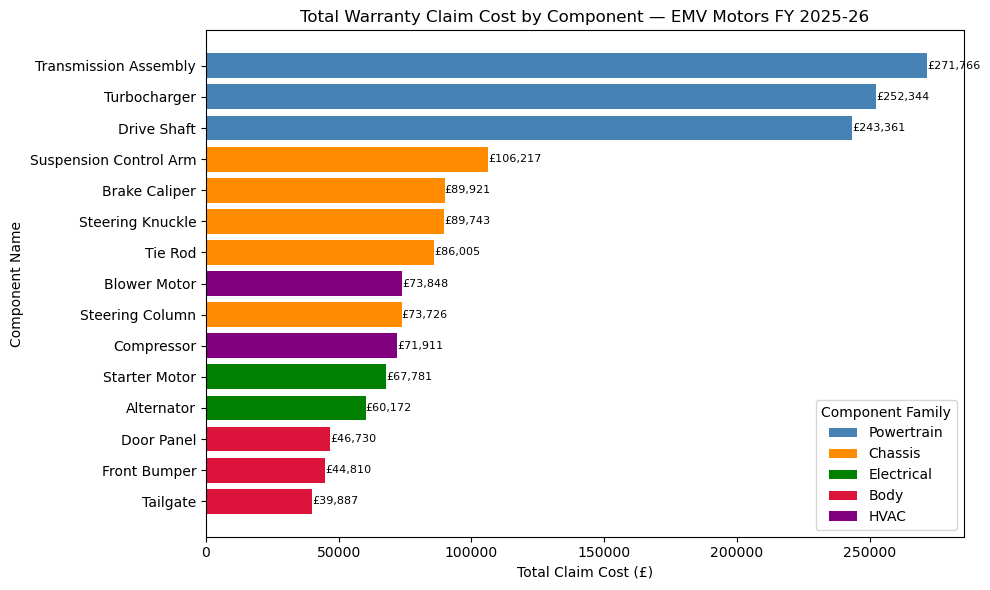

In [90]:
family_colors = {
    'Powertrain': 'steelblue',
    'Chassis': 'darkorange',
    'Electrical': 'green',
    'Body': 'crimson',
    'HVAC': 'purple'
}

colors = component_cost['family'].map(family_colors)

plt.figure(figsize=(10, 6))
plt.barh(component_cost['component_name'],component_cost['total_claim_cost_gbp'],color=colors)

for index, value in enumerate(component_cost['total_claim_cost_gbp']):
    plt.text(value, index, f'£{value:,.0f}', va='center', fontsize=8)

legend_elements = [Patch(facecolor=color, label=family)
                   for family, color in family_colors.items()]
plt.legend(handles=legend_elements, title='Component Family', loc='lower right')

plt.xlabel('Total Claim Cost (£)')
plt.ylabel('Component Name')
plt.title('Total Warranty Claim Cost by Component - EMV Motors FY 2025-26')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [91]:
powertrain_cost = component_cost[component_cost['family'] == 'Powertrain']['total_claim_cost_gbp'].sum()
total_cost = component_cost['total_claim_cost_gbp'].sum()
print(f"Powertrain share: {powertrain_cost/total_cost*100:.1f}%")

Powertrain share: 47.4%


##### Powertrain components account for 47.4% (£767,037) of total warranty expenditure (£1,618,223). Transmission Assembly (£271,766), Turbocharger (£252,344) and Drive Shaft (£243,361) are the three highest cost contributors - collectively responsible for nearly 30% of all warranty spend. 
##### Claim rates are broadly consistent across components (27–33%), confirming that cost differences are driven by repair cost per claim rather than failure frequency. 
##### The Engineering team should prioritise root cause investigation for these three Powertrain components.

### Q2 - Which use cases report most claims across geographic markets?

In [92]:
pivot =(df_claims.pivot_table(index="use_case",columns="market_region",values="claim_id",aggfunc="count",fill_value=0))
print(pivot)

market_region  Americas   EU  MENA   UK
use_case                               
Commercial          115  139   106  138
Commuting           135  129   127  125
Leisure             142  124   129  108
Off-roading         123  126   114  120


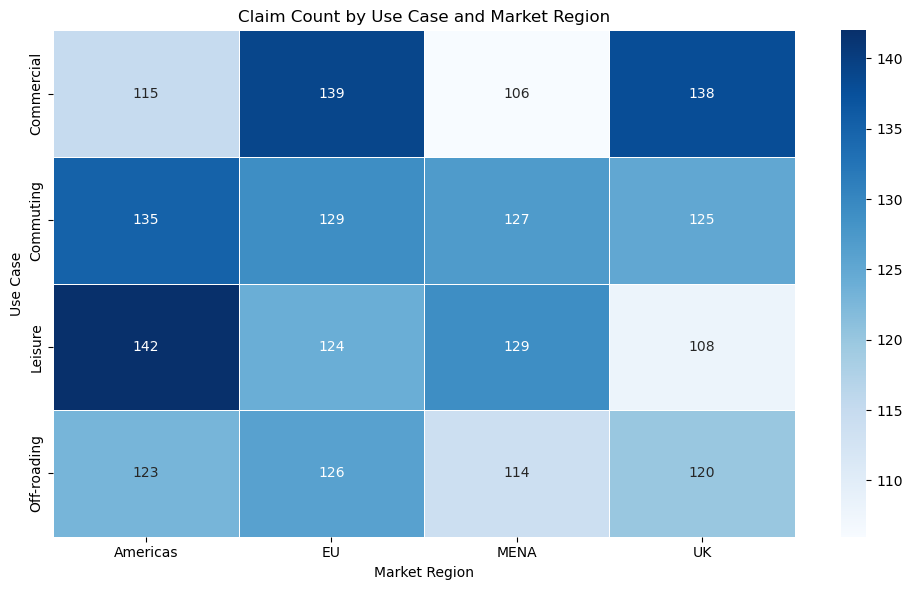

In [93]:
plt.figure(figsize=(10, 6))
sns.heatmap(    pivot,    annot=True,    fmt='d',
    cmap='Blues',   # light = fewer claims, dark = more claims
    linewidths=0.5)
plt.title("Claim Count by Use Case and Market Region")
plt.xlabel("Market Region")
plt.ylabel("Use Case")
plt.tight_layout()
plt.show()

##### Americas + Leisure (142) and EU + Commercial (139) are the highest claim combinations. 
##### UK + Leisure (108) reports the fewest claims. MENA shows relatively moderate claim counts across all use cases - contrary to initial expectations. 
##### Regional Quality teams should investigate the Americas and EU markets, particularly for Leisure and Commercial use cases, to identify environment or usage-driven failure patterns.

### Q3 - Does supplier quality score correlate with claim cost?

In [110]:
supplier_cost = (df_claims.groupby("supplier_code").agg(
    avg_claim_cost=("claim_cost_gbp", "mean"),
    total_claim_cost=("claim_cost_gbp", "sum")
    ).reset_index()
)
print(supplier_cost)

  supplier_code  avg_claim_cost  total_claim_cost
0     38HY-F9SX      802.082087          92239.44
1     AK1V-RJNV     1572.379640         655682.31
2     B9M8-0O2R      956.391171         106159.42
3     F1CB-FNO6      755.138129         104964.20
4     GFYG-WWQC      522.110987         206233.84
5     HBRP-OIG8      737.984651          95200.02
6     MECO-SFOG      661.085649         259806.66
7     YR3X-KXWN      325.372591          97937.15


In [111]:
supplier_cost = supplier_cost.merge(
    df_suppliers[["supplier_code", "quality_score", "tier"]],
    on="supplier_code",
    how="left"
)
print(supplier_cost)

  supplier_code  avg_claim_cost  total_claim_cost  quality_score    tier
0     38HY-F9SX      802.082087          92239.44              6  Tier 2
1     AK1V-RJNV     1572.379640         655682.31              7  Tier 1
2     B9M8-0O2R      956.391171         106159.42              6  Tier 2
3     F1CB-FNO6      755.138129         104964.20              9  Tier 2
4     GFYG-WWQC      522.110987         206233.84              8  Tier 1
5     HBRP-OIG8      737.984651          95200.02             10  Tier 2
6     MECO-SFOG      661.085649         259806.66              5  Tier 1
7     YR3X-KXWN      325.372591          97937.15             10  Tier 1


In [112]:
print("Suppliers df codes:", df_suppliers['supplier_code'].tolist())
print("Claims supplier codes:", df_claims['supplier_code'].unique().tolist())

Suppliers df codes: ['AK1V-RJNV', 'HBRP-OIG8', 'F1CB-FNO6', 'GFYG-WWQC', '38HY-F9SX', 'B9M8-0O2R', 'MECO-SFOG', 'YR3X-KXWN']
Claims supplier codes: ['GFYG-WWQC', 'YR3X-KXWN', 'MECO-SFOG', 'AK1V-RJNV', '38HY-F9SX', 'HBRP-OIG8', 'F1CB-FNO6', 'B9M8-0O2R']


In [113]:
supplier_cost = (df_claims.groupby("supplier_code").agg(avg_claim_cost=("claim_cost_gbp", "mean"),
                total_claim_cost=("claim_cost_gbp", "sum")).reset_index()
)

supplier_cost = supplier_cost.merge(
    df_suppliers[["supplier_code", "quality_score", "tier"]],on="supplier_code",how="left")

print(supplier_cost)

  supplier_code  avg_claim_cost  total_claim_cost  quality_score    tier
0     38HY-F9SX      802.082087          92239.44              6  Tier 2
1     AK1V-RJNV     1572.379640         655682.31              7  Tier 1
2     B9M8-0O2R      956.391171         106159.42              6  Tier 2
3     F1CB-FNO6      755.138129         104964.20              9  Tier 2
4     GFYG-WWQC      522.110987         206233.84              8  Tier 1
5     HBRP-OIG8      737.984651          95200.02             10  Tier 2
6     MECO-SFOG      661.085649         259806.66              5  Tier 1
7     YR3X-KXWN      325.372591          97937.15             10  Tier 1


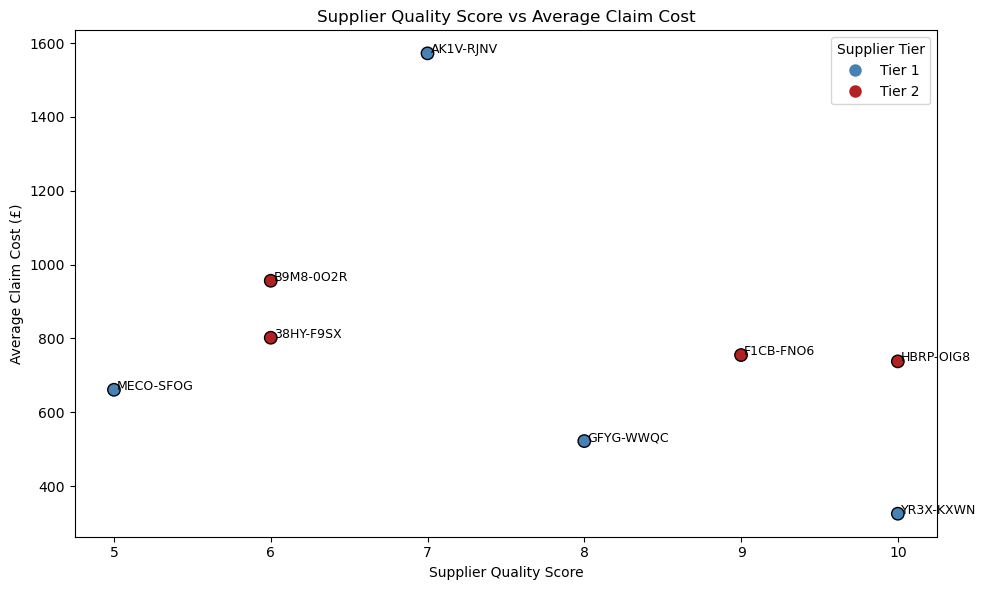

In [114]:
plt.figure(figsize=(10, 6))
tier_colors = {
    "Tier 1": "steelblue",
    "Tier 2": "firebrick"
}
colors = supplier_cost["tier"].map(tier_colors)

plt.scatter(
    supplier_cost["quality_score"],
    supplier_cost["avg_claim_cost"],
    c=colors,
    s=80,
    edgecolor="black"
)

for _, row in supplier_cost.iterrows():
    plt.text(
        row["quality_score"] + 0.02,   # slight offset
        row["avg_claim_cost"],
        row["supplier_code"],
        fontsize=9
    )

plt.xlabel("Supplier Quality Score")
plt.ylabel("Average Claim Cost (£)")
plt.title("Supplier Quality Score vs Average Claim Cost")

handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=tier_colors["Tier 1"], markersize=10, label="Tier 1"),
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=tier_colors["Tier 2"], markersize=10, label="Tier 2")
]
plt.legend(handles=handles, title="Supplier Tier")

plt.tight_layout()
plt.show()

In [115]:
print(df_components.columns.tolist())

['name', 'family', 'primary_supplier', 'component_code']


In [116]:
print(df_components[['name', 'family', 'primary_supplier']])

                      name      family primary_supplier
0             Turbocharger  Powertrain        AK1V-RJNV
1            Brake Caliper     Chassis        AK1V-RJNV
2    Transmission Assembly  Powertrain        AK1V-RJNV
3              Drive Shaft  Powertrain        AK1V-RJNV
4               Alternator  Electrical        GFYG-WWQC
5            Starter Motor  Electrical        GFYG-WWQC
6             Blower Motor        HVAC        GFYG-WWQC
7               Compressor        HVAC        GFYG-WWQC
8         Steering Knuckle     Chassis        MECO-SFOG
9                  Tie Rod     Chassis        MECO-SFOG
10         Steering Column     Chassis        MECO-SFOG
11  Suspension Control Arm     Chassis        MECO-SFOG
12              Door Panel        Body        YR3X-KXWN
13            Front Bumper        Body        YR3X-KXWN
14                Tailgate        Body        YR3X-KXWN


##### Supplier quality score does not reliably predict average claim cost. AK1V-RJNV (Tier 1, score 7) shows the highest average claim cost at £1,572, 
##### While YR3X-KXWN (Tier 1, score 10) shows the lowest at £325 - both are Tier 1 suppliers yet their costs differ by nearly 5x. 
##### This confirms that component family is the primary confounding variable - Powertrain suppliers generate higher average costs regardless of quality score. A fair supplier evaluation must normalise for component type before drawing performance conclusions.

### Q4 - What is the cost of claims within 6 and 12 months of sale?

In [104]:
df_claims["time_bucket"] = np.select(
    [
        df_claims["days_since_sale"].between(0, 180),
        df_claims["days_since_sale"].between(181, 365),
        df_claims["days_since_sale"] > 365
    ],
    [
        "0-6 Months",
        "6-12 Months",
        "Beyond 12 Months"
    ],
    default="Unknown"
)
print(df_claims['time_bucket'].value_counts())

time_bucket
0-6 Months          701
6-12 Months         682
Beyond 12 Months    617
Name: count, dtype: int64


In [105]:
time_analysis = (df_claims.groupby("time_bucket").agg(total_claim_cost=("claim_cost_gbp", "sum"),
        avg_claim_cost=("claim_cost_gbp", "mean"),
        claim_count=("claim_id", "count")
    ).reset_index()
)
print(time_analysis)

        time_bucket  total_claim_cost  avg_claim_cost  claim_count
0        0-6 Months         572270.04      816.362397          701
1       6-12 Months         557734.79      817.792947          682
2  Beyond 12 Months         488218.21      791.277488          617


In [106]:
bucket_order = ["0-6 Months", "6-12 Months", "Beyond 12 Months"]
time_analysis["time_bucket"] = pd.Categorical(
    time_analysis["time_bucket"], 
    categories=bucket_order, 
    ordered=True
)
time_analysis = time_analysis.sort_values("time_bucket")

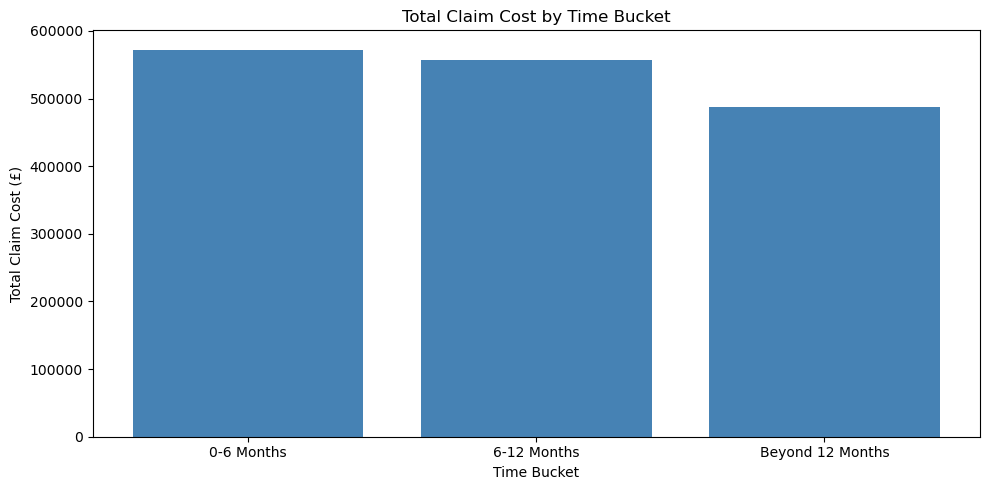

In [107]:
plt.figure(figsize=(10, 5))
plt.bar(
    time_analysis["time_bucket"],
    time_analysis["total_claim_cost"],
    color="steelblue"
)
plt.title("Total Claim Cost by Time Bucket")
plt.xlabel("Time Bucket")
plt.ylabel("Total Claim Cost (£)")
plt.tight_layout()
plt.show()

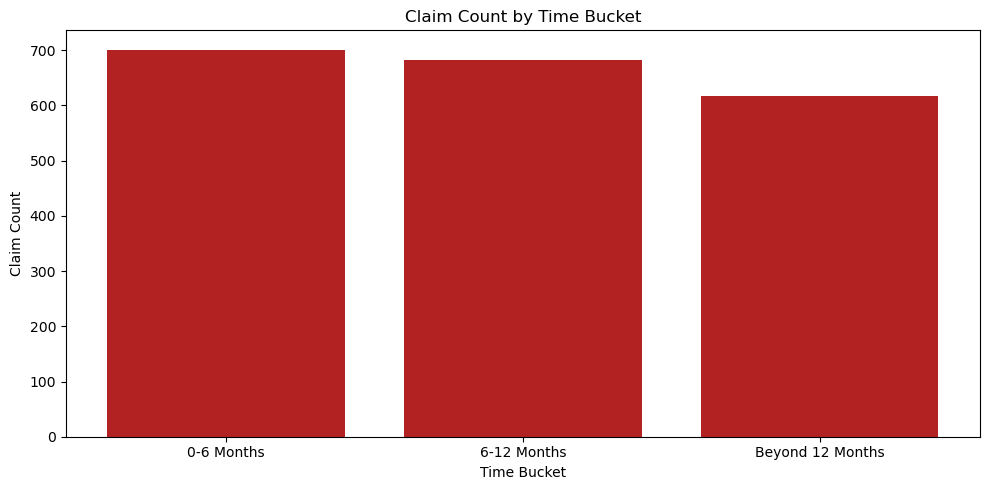

In [108]:
plt.figure(figsize=(10, 5))
plt.bar(
    time_analysis["time_bucket"],
    time_analysis["claim_count"],
    color="firebrick"
)
plt.title("Claim Count by Time Bucket")
plt.xlabel("Time Bucket")
plt.ylabel("Claim Count")
plt.tight_layout()
plt.show()

##### Early-life failures (0–6 months) generate the highest total claim cost at £572,270 across 701 claims, followed by 6–12 months (£557,735, 682 claims) and Beyond 12 months (£488,218, 617 claims).
##### Average cost per claim is consistent across all three windows (£791–£817), confirming that claim volume - not severity - drives the cost difference. 
##### The declining volume with vehicle age points to manufacturing and assembly issues as the primary root cause. 
##### The Engineering team should focus quality intervention at the production and assembly stage to reduce early-life claim rates.

### Q5 - Has warranty cost increased across FY 2025-26?

In [117]:
df_claims['claim_date'] = pd.to_datetime(df_claims['claim_date'])
df_claims['sale_date'] = pd.to_datetime(df_claims['sale_date'])
df_claims["claim_month"] = df_claims["claim_date"].dt.strftime("%Y-%m")

In [118]:
monthly_trend = (df_claims.groupby("claim_month").agg(total_claim_cost=("claim_cost_gbp", "sum"),
        claim_count=("claim_id", "count")
    ).reset_index()
)
print(monthly_trend)

   claim_month  total_claim_cost  claim_count
0      2024-10           6813.01            9
1      2024-11          15397.25           17
2      2024-12          29944.06           36
3      2025-01          39407.42           54
4      2025-02          43596.21           41
5      2025-03          49425.10           72
6      2025-04          66921.58           84
7      2025-05          85763.90          103
8      2025-06         101706.85          114
9      2025-07          89344.22          107
10     2025-08          97516.73          118
11     2025-09          85356.25          109
12     2025-10          85218.37          102
13     2025-11          78513.77           97
14     2025-12          80722.45          112
15     2026-01          90950.48          126
16     2026-02          94751.86           99
17     2026-03          92523.41          109
18     2026-04          78705.17           93
19     2026-05          75633.81           84
20     2026-06          56564.12  

In [119]:
#filtered data till claims March 2026
monthly_trend_filtered = monthly_trend[monthly_trend['claim_month'] <= '2026-03']
print(monthly_trend_filtered)

   claim_month  total_claim_cost  claim_count
0      2024-10           6813.01            9
1      2024-11          15397.25           17
2      2024-12          29944.06           36
3      2025-01          39407.42           54
4      2025-02          43596.21           41
5      2025-03          49425.10           72
6      2025-04          66921.58           84
7      2025-05          85763.90          103
8      2025-06         101706.85          114
9      2025-07          89344.22          107
10     2025-08          97516.73          118
11     2025-09          85356.25          109
12     2025-10          85218.37          102
13     2025-11          78513.77           97
14     2025-12          80722.45          112
15     2026-01          90950.48          126
16     2026-02          94751.86           99
17     2026-03          92523.41          109


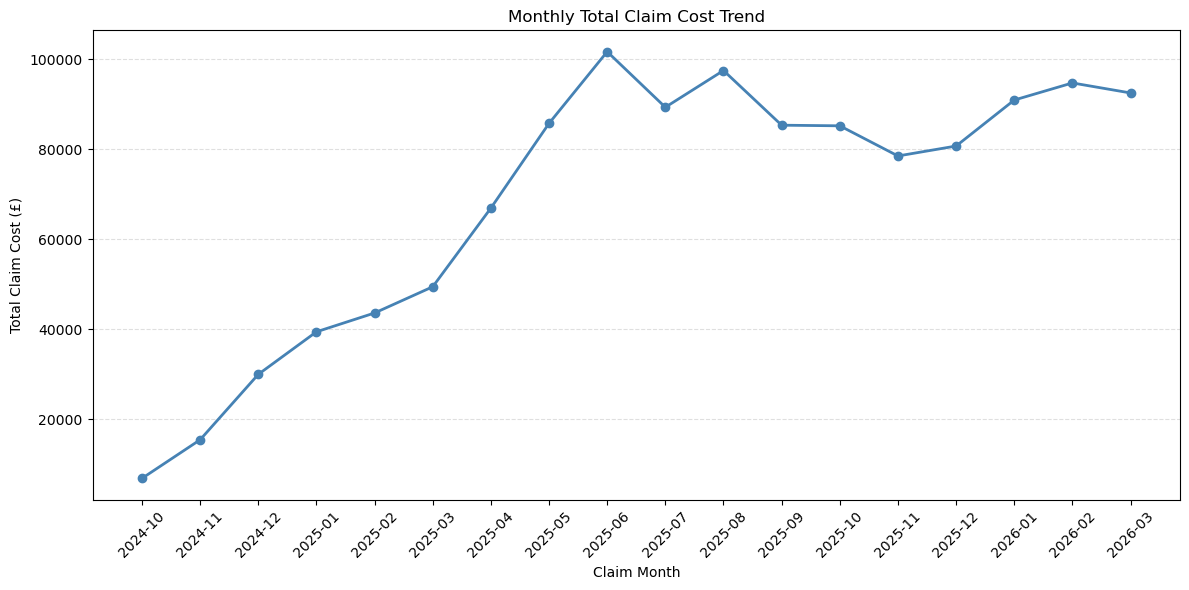

In [120]:
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_trend_filtered["claim_month"],
    monthly_trend_filtered["total_claim_cost"],
    marker="o",
    linewidth=2,
    color="steelblue"
)

plt.title("Monthly Total Claim Cost Trend")
plt.xlabel("Claim Month")
plt.ylabel("Total Claim Cost (£)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

In [121]:
cost_2024 = monthly_trend_filtered[monthly_trend_filtered['claim_month'].str.startswith('2024')]['total_claim_cost'].sum()
cost_2025 = monthly_trend_filtered[monthly_trend_filtered['claim_month'].str.startswith('2025')]['total_claim_cost'].sum()

print(f"2024 total: £{cost_2024:,.0f}")
print(f"2025 total: £{cost_2025:,.0f}")
print(f"YoY change: {((cost_2025 - cost_2024) / cost_2024 * 100):.1f}%")

2024 total: £52,154
2025 total: £903,493
YoY change: 1632.3%


In [122]:
df_claims["claim_month_dt"] = pd.to_datetime(df_claims["claim_month"], format="%Y-%m")

df_claims["year"] = df_claims["claim_month_dt"].dt.year
df_claims["month"] = df_claims["claim_month_dt"].dt.month
df_claims["quarter"] = np.select(
    [
        (df_claims["year"] == 2024) & (df_claims["month"].between(10, 12)),
        (df_claims["year"] == 2025) & (df_claims["month"].between(1, 3)),
        (df_claims["year"] == 2025) & (df_claims["month"].between(4, 6)),
        (df_claims["year"] == 2025) & (df_claims["month"].between(7, 9)),
        (df_claims["year"] == 2025) & (df_claims["month"].between(10, 12)),
        (df_claims["year"] == 2026) & (df_claims["month"].between(1, 3)),
    ],
    [
        "Q4 2024",
        "Q1 2025",
        "Q2 2025",
        "Q3 2025",
        "Q4 2025",
        "Q1 2026"
    ],
    default="Other"
)

In [123]:
print(df_claims['quarter'].value_counts().sort_index())

quarter
Other      491
Q1 2025    167
Q1 2026    334
Q2 2025    301
Q3 2025    334
Q4 2024     62
Q4 2025    311
Name: count, dtype: int64


In [124]:
print(df_claims[df_claims['quarter'] == 'Other']
      [['claim_date', 'claim_month', 'year', 'month']].head(10))

   claim_date claim_month  year  month
7  2026-04-04     2026-04  2026      4
13 2026-06-29     2026-06  2026      6
15 2026-04-03     2026-04  2026      4
16 2026-11-16     2026-11  2026     11
20 2026-06-10     2026-06  2026      6
21 2026-05-05     2026-05  2026      5
24 2026-06-24     2026-06  2026      6
27 2026-04-06     2026-04  2026      4
29 2026-06-05     2026-06  2026      6
31 2026-08-29     2026-08  2026      8


In [125]:
quarterly_cost = (
    df_claims[df_claims['quarter'] != 'Other']
    .groupby('quarter')
    .agg(
        total_claim_cost=('claim_cost_gbp', 'sum'),
        claim_count=('claim_id', 'count')
    )
    .reset_index()
)
print(quarterly_cost)

   quarter  total_claim_cost  claim_count
0  Q1 2025         132428.73          167
1  Q1 2026         278225.75          334
2  Q2 2025         254392.33          301
3  Q3 2025         272217.20          334
4  Q4 2024          52154.32           62
5  Q4 2025         244454.59          311


In [127]:
quarterly_trend = quarterly_cost[quarterly_cost["quarter"] != "Other"].copy()

In [128]:
quarter_order = ['Q4 2024', 'Q1 2025', 'Q2 2025', 'Q3 2025', 'Q4 2025', 'Q1 2026']
quarterly_cost['quarter'] = pd.Categorical(quarterly_cost['quarter'], categories=quarter_order, ordered=True)
quarterly_cost = quarterly_cost.sort_values('quarter')
print(quarterly_cost)

   quarter  total_claim_cost  claim_count
4  Q4 2024          52154.32           62
0  Q1 2025         132428.73          167
2  Q2 2025         254392.33          301
3  Q3 2025         272217.20          334
5  Q4 2025         244454.59          311
1  Q1 2026         278225.75          334


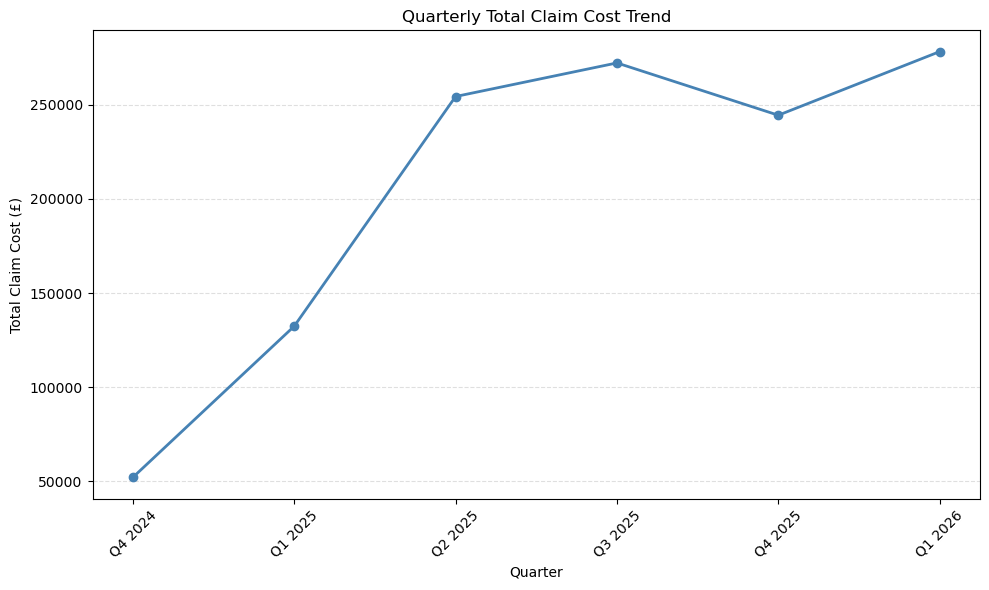

In [129]:
plt.figure(figsize=(10, 6))
plt.plot(
    quarterly_cost["quarter"],
    quarterly_cost["total_claim_cost"],
    marker="o",
    linewidth=2,
    color="steelblue"
)

plt.title("Quarterly Total Claim Cost Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Claim Cost (£)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

In [130]:
q4_2024 = quarterly_cost[quarterly_cost['quarter'] == 'Q4 2024']['total_claim_cost'].values[0]
q1_2026 = quarterly_cost[quarterly_cost['quarter'] == 'Q1 2026']['total_claim_cost'].values[0]
print(f"Increase: {((q1_2026 - q4_2024) / q4_2024 * 100):.1f}%")

Increase: 433.5%


In [132]:
powertrain_cost = component_cost[component_cost['family'] == 'Powertrain']['total_claim_cost_gbp'].sum()
total_cost = component_cost['total_claim_cost_gbp'].sum()
print(f"Powertrain share: {powertrain_cost/total_cost*100:.1f}%")
print(f"Total warranty cost: £{total_cost:,.0f}")

Powertrain share: 47.4%
Total warranty cost: £1,618,223


##### Warranty claim costs have increased by 433.5% over six quarters, from £52,154 in Q4 2024 to £278,226 in Q1 2026.
##### Growth was steepest between Q1 and Q3 2025 (£132,429 to £272,217), before a slight dip in Q4 2025 (£244,455) and a recovery to a new high in Q1 2026. The overall trend shows no sign of reversal. 
##### Powertrain component failures, accounting for 47.4% of total spend, are the primary driver of this escalation. 
##### Urgent intervention is required to achieve the targeted 10% cost reduction by Q3 2026.

In [134]:
print(component_cost[['component_name', 'family', 'total_claim_cost_gbp', 'claim_rate']].sort_values('total_claim_cost_gbp', ascending=False).to_string())
print(pivot)
print(supplier_cost[['supplier_code', 'avg_claim_cost', 'quality_score', 'tier']])
print(time_analysis)
print(quarterly_cost)
print(f"Increase: {((q1_2026 - q4_2024) / q4_2024 * 100):.1f}%")

            component_name      family  total_claim_cost_gbp  claim_rate
0    Transmission Assembly  Powertrain             271766.44      0.2945
1             Turbocharger  Powertrain             252343.84      0.2722
2              Drive Shaft  Powertrain             243361.33      0.3064
3   Suspension Control Arm     Chassis             106217.10      0.3285
4            Brake Caliper     Chassis              89921.16      0.3131
5         Steering Knuckle     Chassis              89743.04      0.2933
6                  Tie Rod     Chassis              86005.06      0.2785
7             Blower Motor        HVAC              73848.15      0.2835
8          Steering Column     Chassis              73726.30      0.2826
9               Compressor        HVAC              71911.21      0.3039
10           Starter Motor  Electrical              67781.18      0.2834
11              Alternator  Electrical              60171.84      0.2837
12              Door Panel        Body             